In [17]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
files = glob.glob('./dataview/*.xlsx')
files = [file for file in files if 'CoT' not in file]

scenario_map = {
    'binary-tree': 'Binary Tree',
    'multiple-tree': 'Multiple Tree',
    'JSON': 'JSON',
    'formula': 'Formula',
    'code': 'Code',
    'paper': 'Paper'
}

dfs = dict()

for file in files:
    try:
        scenario = scenario_map[os.path.basename(file).rstrip('.xlsx')]
        dfs[scenario] = pd.read_excel(file, sheet_name='ExampleType')
    except ValueError:
        continue

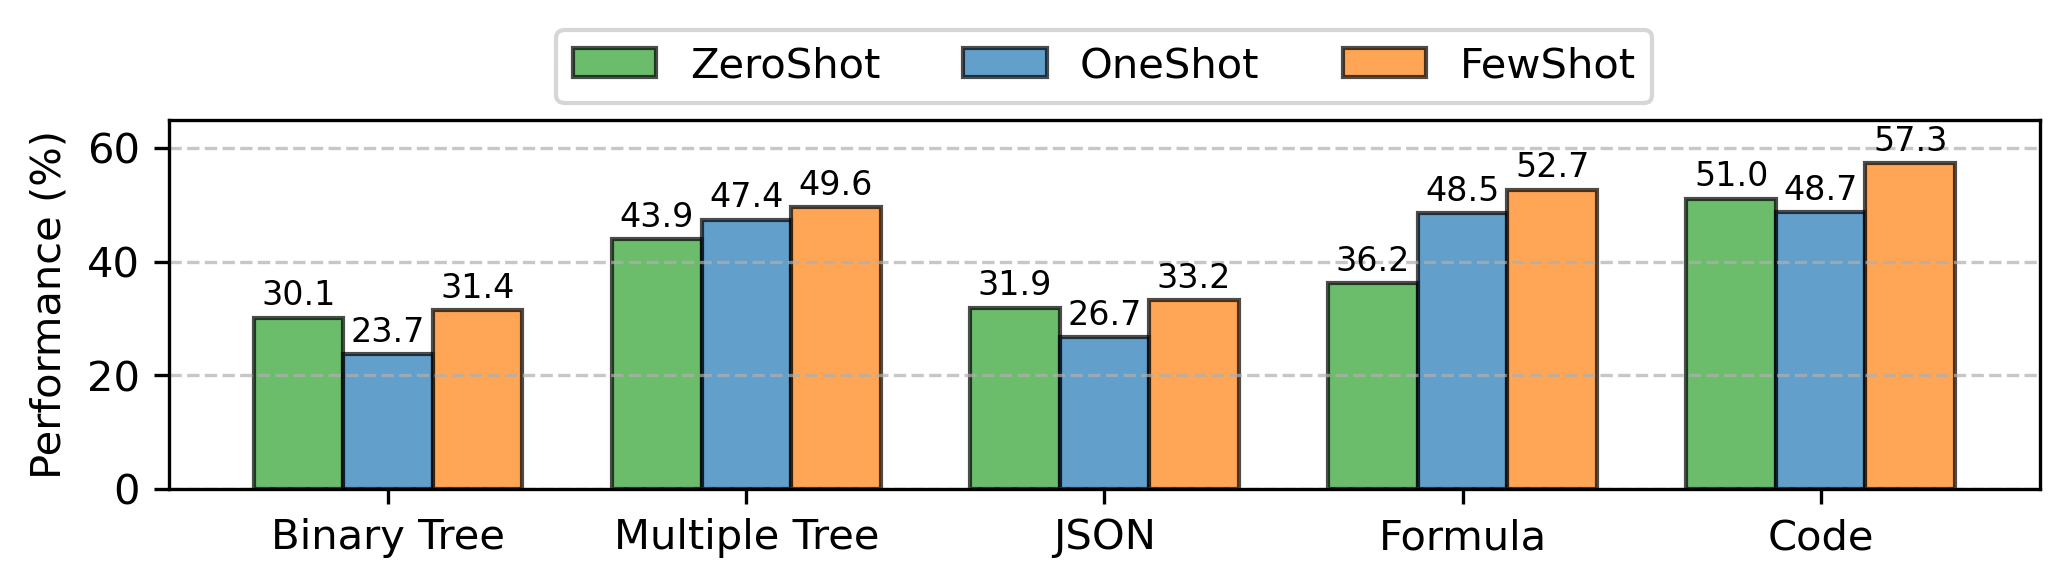

In [31]:
example_order = ['ZeroShot', 'OneShot', 'FewShot']
colors = {'ZeroShot': '#2ca02c', 'OneShot': '#1f77b4', 'FewShot': '#ff7f0e'}
scenario_order = ['Binary Tree', 'Multiple Tree', 'JSON', 'Formula', 'Code']


fig, ax = plt.subplots(figsize=(7, 2.2), dpi=300)

bar_width = 0.25
index = range(len(scenario_order))

for i, scenario in enumerate(scenario_order):
    df = dfs[scenario]
    filtered_data = df[df['ExampleType'].isin(example_order)]
    filtered_data = filtered_data.set_index('ExampleType').reindex(example_order).reset_index()

    bars = []
    for j, example_type in enumerate(example_order):
        example_type_data = filtered_data[filtered_data['ExampleType'] == example_type]
        bar = ax.bar(
            index[i] + bar_width * j, example_type_data['mean'].values[0], 
            color=colors[example_type], width=bar_width, alpha=0.7, label=example_type if i == 0 else "")
        bars.append(bar)

    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2, height + 1, f'{height:.1f}', 
                    ha='center', va='bottom', fontsize=8)

for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1)
    
# ax.set_xlabel('Scenarios')
ax.set_ylabel('Performance (%)')
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(scenario_order)
ax.set_ylim(0, 65)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=3)

plt.tight_layout()
plt.savefig('../Images/example_type.pdf')

In [3]:
import glob
files = glob.glob('./format-results/*.csv')


example_models = ['Meta-Llama-3.1-8B-Instruct', 'Qwen2.5-7B-Instruct']

llama_data = list()
qwen_data  = list()

for file in files:
    df = pd.read_csv(file)
    # skip bullshit in JSON analysis.
    if 'JSON' in file:
        df_temp = df[df['Mode'] != 'bullshit']
    if 'paper' in file:
        continue

    zero_shot_models = df['ModelName'][df['ExampleType'] == 'ZeroShot']
    one_shot_models  = df['ModelName'][df['ExampleType'] == 'OneShot']
    few_shot_models  = df['ModelName'][df['ExampleType'] == 'FewShot']
    llama = df[df['ModelName'] == example_models[0]]
    qwen  = df[df['ModelName'] == example_models[1]]

    llama_data.append(llama.groupby('ExampleType')['Accuracy'].mean())
    qwen_data.append(qwen.groupby('ExampleType')['Accuracy'].mean())
    
llama_data, qwen_data

([ExampleType
  FewShot      3.497140
  OneShot      5.887078
  ZeroShot    33.625494
  Name: Accuracy, dtype: float64,
  ExampleType
  FewShot     39.25
  OneShot     58.25
  ZeroShot    61.75
  Name: Accuracy, dtype: float64,
  ExampleType
  FewShot      1.376111
  OneShot      1.665556
  ZeroShot    14.737778
  Name: Accuracy, dtype: float64,
  Series([], Name: Accuracy, dtype: float64),
  ExampleType
  FewShot     18.621296
  OneShot     10.080000
  ZeroShot    28.762037
  Name: Accuracy, dtype: float64,
  Series([], Name: Accuracy, dtype: float64),
  ExampleType
  FewShot      0.3216
  OneShot      1.8730
  ZeroShot    34.1798
  Name: Accuracy, dtype: float64],
 [ExampleType
  FewShot     61.728971
  OneShot     58.816379
  ZeroShot    51.174671
  Name: Accuracy, dtype: float64,
  ExampleType
  FewShot     64.25
  OneShot     63.50
  ZeroShot    69.25
  Name: Accuracy, dtype: float64,
  ExampleType
  FewShot     35.738472
  OneShot     31.494167
  ZeroShot    33.108472
  Name: Acc